# 语言的序章：分词与情感分析初探

从本章开始，我们将正式踏入自然语言处理（NLP）的领域。通过本次实践，你将了解 NLP 任务的基本流程，并学会如何搭建与训练一个文本分类模型。

## 任务背景

随着品类的不断丰富，你的无人柠檬水摊位已成功升级为一家无人奶茶店，生意日益红火。每天，店铺都会收到成百上千条来自顾客的评价。虽然其中不乏积极的反馈，但也存在许多表达不满的意见。为了更高效地处理这些评价，你计划开发一个能够自动对顾客情感进行分类的系统。通过准确识别用户的情感倾向，可以快速定位那些表达不满的评价，从而进一步优化产品，提升客户满意度。

然而，你很快发现了一个核心难题：顾客的评价是“好喝！”、“珍珠太硬了”、“服务太慢，差评！”这样的自然语言文本。你之前成功应用的神经网络模型，擅长处理的是柠檬水的配方比例、温度、糖度这类结构化的数值数据。它无法直接理解“差评”这两个字背后所蕴含的负面情绪。

这就引出了一个更根本的问题：**我们该如何让计算机理解并处理“人类语言”呢？**

## 最少必要知识
- 自然语言处理
- 分词器（Tokenizer）

## 任务鸟瞰

### 任务分析

本次的任务是训练一个情感分析模型，它能够识别出顾客评价的情感倾向，并给出相应的概率。

![情感分析模型任务鸟瞰](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260203144622.png)

本次的模型包含三个层：输入层、隐藏层和输出层。
- **输入层**：接收顾客评价数据，并生成相应的隐藏特征。
- **隐藏层**：进一步组合隐藏特征，生成更复杂的特征表示。
- **输出层**：则根据顾客评价的特征表示，生成相应情感类型的预测得分。

### 模型结构

在前几章中，我们利用神经网络成功解决了回归与分类问题，但所处理的特征均为结构化的数值类型。本章我们将涉足一个经典而实用的自然语言处理任务——情感分析。我们会训练一个能够自动判别顾客评价中蕴含的情感倾向（正面或负面）的模型。由于该任务相对更为复杂，我们需要进一步加深模型结构，以提升模型的表示能力。

顾客评价情感分析模型的结构如下图所示：

![情感分析模型结构](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260203144643.png)

NLP 任务的通用开发流程包含如下步骤：定义分词器、数据准备、模型定义、模型训练与模型评估。我们会按照这个顺序组织本章的内容，在正式开始之前，先打印环境的版本号，避免因为环境不同而导致程序不能复现。

### 环境版本

In [1]:
from util import show_version

show_version()

本书愿景：
+------+--------------------------------------------------------+
| Info |                   《动手学人工智能》                   |
+------+--------------------------------------------------------+
| 作者 |                       吾辈亦有感                       |
| 哔站 |      https://space.bilibili.com/3546632320715420       |
| 定位 | 基于'从零构建'的理念，用实战帮助程序员快速入门大模型。 |
| 愿景 | 若让你的AI学习之路走的更容易一点，我将倍感荣幸！祝好😄 |
+------+--------------------------------------------------------+
环境信息：
+-------------+--------------+------------------------+
| Python 版本 | PyTorch 版本 | PyTorch Lightning 版本 |
+-------------+--------------+------------------------+
|   3.12.12   |    2.9.1     |         2.6.0          |
+-------------+--------------+------------------------+


## 自定义分词器

我们该如何让计算机理解并处理“人类语言”呢？这是我们踏入自然语言处理世界所需要解决的第一个挑战。

假设有两条这样的顾客评价：
- `珍珠太硬了`
- `非常不错，强烈推荐`

我们应该如何让模型进行处理呢？在 NLP 中，我们会使用**分词器**（Tokenizer）来解决这个问题。分词器（Tokenizer）是自然语言从“人类可读”到“机器可算”的关键枢纽，其有两个核心功能：
- **编码**：将“自然语言→数字序列”，让模型能够处理人类的语言。
- **解码**：将“模型输出→自然语言”，让人类能够看懂模型的预测。


这里会设计两个核心问题需要解决：
1. 如何将人类语言翻译成计算机能够理解的“语言”，也就是数字？
2. 如何处理长短不一的变长文本数据，让模型可以批量进行计算？


### 翻译人类的语言

计算机无法直接理解人类的语言。因此，我们需要将人类语言翻译成计算机能够理解的数字序列。具体过程如下所示：

![分词词编码](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260203165043.png)

这个过程通常分为三个关键步骤：

#### 第一步：词元化（Tokenization）
计算机无法直接理解一个完整的句子。因此，我们需要将连续的文本序列，切割成一个个有意义的、可处理的基本单元，这些单元被称为**词元**（Token）。对于中文来说，这个过程尤为关键。
- **以字符为单位**：最直接的方式是将句子切分成单个汉字。例如，“珍珠太硬了”会被切分成 `['珍', '珠', '太', '硬', '了']`。
- **以词语为单位**：更符合语言习惯的方式是切分成词语。例如，“珍珠太硬了”会被切分成 `['珍珠', '太', '硬', '了']`。

词元化是NLP的基石。不同的切分方式会直接影响后续模型对语义的理解。例如，“南京市长江大桥”按字符切分和按词语切分（如`['南京', '市长', '江大桥']` vs `['南京市', '长江大桥']`）的含义天差地别。

#### 第二步：构建词表（Vocabulary Building）
词元化之后，我们得到了大量离散的词元。为了将它们转化为数值，我们首先需要建立一个**词表**（Vocabulary）。词表是一个从词元到唯一 ID（索引）的映射，它定义了模型所能“认识”的所有基本词汇。

我们收集所有训练数据中出现的词元，并为每个独特的词元分配一个 ID。例如，基于我们的数据，如果采用字符级分词，我们可能构建出这样一个词表：`{'珍': 1, '珠': 2, '太': 3, '硬': 4, '了': 5, '好': 6, '喝': 7, '差': 8, '评': 9, ...}`。

#### 第三步：序列化（Encoding）

有了词表，我们就可以将任何词元化后的句子，通过查找词表，转换成对应的数字ID序列。

例如，句子“珍珠太硬了”在**字符级词元化**后的结果是 `['珍', '珠', '太', '硬', '了']`。根据上面的词表查找 Token 对应的 ID，它就被序列化为数字ID序列：`[1, 2, 3, 4, 5]`。
如果遇到一个词表中没有的词（如“芋”），我们则用一个统一的 ID（例如`-1`）来表示。

现在，我们成功地将一句自然语言文本，转化成了一个模型可以接收的数值序列。这串数字虽然丢失了词语原本的形态，但它携带了句子的结构信息，是计算机理解文本语义的起点。

### 处理变长的文本

模型的批量处理机制要求输入数据具有统一的长度，因此，将不同长度的文本序列调整为固定长度是文本预处理流程中不可或缺的一环，实现文本长度统一的核心操作是“填充”（Padding）和“截断”（Truncation）。

填充和截断如下所示（目标长度为 5）：

![填充和截断](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260203173208.png)

#### 填充（Padding）
填充是指在较短的序列末尾或开头添加特定的填充值，使其长度达到预设的统一长度。
- 操作：我们首先需要设定一个固定的序列长度（例如，10 个词元）。对于所有短于此长度的序列，我们在其末尾添加一个统一的填充值（例如，数字 `0` ），直到其长度达到10。
- 示例：假设我们设定的固定长度为6。对于序列 `[1, 2, 3, 4, 5]`（“珍珠太硬了”），其长度为 5，需要将其填充为 6 的序列 `[1, 2, 3, 4, 5, 0]`

#### 截断（Truncation）
截断是指将过长的序列从头部或尾部截取一部分，使其长度不超过预设的统一长度。
- 操作：对于所有长于预设长度的序列，我们舍弃超出部分。通常可以从序列末尾开始截断（保留开头部分），也可以从开头截断（保留结尾部分），这取决于任务的需要。
- 示例：同样设定固定长度为6。对于过长的序列 `[8, 9, 1, 2, 3, 4, 5]`（“差评珍珠太硬了”），我们从末尾截断，保留前5个词元，得到 `[8, 9, 1, 2, 3, 4]`（即“差评珍珠太硬”）。

通过结合**填充**与**截断**技术，我们可以将任意一批长度不一的文本序列，转换为统一的固定长度数值矩阵，从而使其能够直接作为神经网络模型的输入。

至此，我们已经完成了分词器处理文本的完整流程：**词元化 → 构建词表 → 序列化 → 长度对齐（填充/截断）**。

接下来，我们将尝试自定义一个分词器，并在此基础上构建文本分类模型，学习从文本序列到情感类别（正面/负面）的映射关系，迈出让计算机理解人类情感的第一步。

### 自定义分词器的代码实现

分词器（Tokenizer）将“自然语言→数字序列”，让模型能够处理人类的语言的过程叫做**编码**（encode）。另外，分词器还负责**解码**（decode），将“模型输出→自然语言”，让人类能够看懂模型的预测。

分词器（Tokenizer）是自然语言从“人类可读”到“机器可算”的关键枢纽。

下面定义一个字符级中文分词器（`SimpleTokenizer`），将顾客评论转换为模型可处理的、长度统一的 Token ID 序列。自定义分词器包含以下关键步骤：
- **词元化**：将原始文本分割成模型可处理基本单元（Token）。
- **构建词表**：统计语料中的所有词元，为每个词元分配一个唯一的ID，形成词表（Vocabulary）。
- **添加特殊标记**： 添加一些特殊标记，如填充符（[PAD]）、未知标记（[UNK]）。
- **添加编码方法**：将原始文本编码为模型可处理的输入。
- **添加解码方法**：将模型输出的ID序列转换回自然语言。


In [2]:
class SimpleTokenizer:
    def __init__(self):
        """
        初始化简单分词器
        """
        # 特殊token
        self.pad_token = '[PAD]'
        self.unk_token = '[UNK]'

        # 特殊token ID
        self.pad_token_id = 0
        self.unk_token_id = 1

        # 构建词汇表
        self.vocab = {
            self.pad_token: self.pad_token_id,
            self.unk_token: self.unk_token_id,
        }

        # 反向词汇表 (id -> token)
        self.ids_to_tokens = {v: k for k, v in self.vocab.items()}

        # 词汇表大小
        self.vocab_size = len(self.ids_to_tokens)

    def build_vocab(self, texts):
        """
        根据文本构建词汇表
        """
        for text in texts:
            words = list(text)  # 将每个汉字作为独立token

            for word in words:
                if word not in self.vocab:
                    self.vocab[word] = self.vocab_size
                    self.ids_to_tokens[self.vocab_size] = word
                    self.vocab_size += 1

    def build_vocab_from_file(self, file_path):
        """
        从文件中构建词汇表
        """
        texts = []
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                texts.append(line.strip())

        self.build_vocab(texts)

    def encode(self, text):
        """
        将文本编码为token ids
        """
        tokens = list(text)

        # 转换为IDs
        token_ids = []
        for token in tokens:
            if token in self.vocab:
                token_ids.append(self.vocab[token])
            else:
                token_ids.append(self.unk_token_id)

        return token_ids

    def decode(self, token_ids):
        """
        将token ids解码为文本
        """
        tokens = []
        for token_id in token_ids:
            if token_id in self.ids_to_tokens:
                token = self.ids_to_tokens[token_id]
                # 过滤特殊token（可根据需要调整）
                if token not in [self.pad_token]:
                    tokens.append(token)

        return ''.join(tokens)

    def pad_sequences(self, sequences, max_length):
        """
        对序列进行填充或截断
        """
        padded_sequences = []

        for seq in sequences:
            if len(seq) > max_length:
                # 截断
                padded_seq = seq[:max_length]
            else:
                # 填充
                pad_length = max_length - len(seq)
                padded_seq = seq + [self.pad_token_id] * pad_length

            padded_sequences.append(padded_seq)

        return padded_sequences

    def __call__(self, texts, max_length=128):
        """
        分词器主调用函数
        """
        is_single_text = False

        if isinstance(texts, str):
            is_single_text = True
            texts = [texts]

        # 编码所有文本
        all_token_ids = []
        for text in texts:
            token_ids = self.encode(text)
            all_token_ids.append(token_ids)

        # 填充或截断到统一长度
        padded_token_ids = self.pad_sequences(all_token_ids, max_length)

        if is_single_text:
            padded_token_ids = padded_token_ids[0]

        return padded_token_ids

`SimpleTokenizer` 类的核心功能总结：
1. 初始化与词汇表构建
    - **特殊标记**：分词在初始化时即定义了两种关键的特殊标记及其 ID：填充标记 `[PAD]` (ID为0) 和未知词标记 `[UNK]` (ID为1)。这解决了前文提到的处理未知词汇和统一序列长度的基础问题。
    - **动态构建词表**：提供了 `build_vocab` 和 `build_vocab_from_file` 方法。它们会遍历输入的文本语料，将每个汉字字符视为一个独立的词元（Token），并为其分配一个唯一的 ID，从而动态构建从词元到ID的映射（`self.vocab`）及其反向映射（`self.ids_to_tokens`）。
2. 编码与解码
    - **编码方法 `encode()`**：接收一个字符串，将其按字符拆分为词元列表。然后，它遍历每个词元（字符），在词汇表中查找其对应的ID。如果词元不存在于词汇表中，则使用 `[UNK]` 的 ID（即1）代替。这实现了将“自然语言→数字序列”的转换过程。
    - **解码方法 `decode()`**：接收一个 ID 列表，将其转换回对应的词元（字符）列表。在此过程中，它会过滤掉填充标记 `[PAD]`，最后将词元列表拼接成字符串返回。这实现了“数字序列→自然语言”的转换过程。
3. 序列填充与截断
    - **长度对齐方法 `pad_sequences()`**：该方法接收一个 ID 序列列表和一个目标长度 `max_length`，解决输入文本长度不一的问题。对于每个序列： 
        - 如果序列长于 `max_length`，则进行截断，保留前 `max_length` 个元素。
        - 如果序列短于 `max_length`，则进行填充，在序列末尾添加足够数量的 `[PAD]` 标记 ID（即0），使其达到目标长度。 
4. 主调用接口
    - **`__call__()`**：集成了文本编码与序列长度对齐的完整流程。它支持接收单条文本或文本列表作为输入，并可指定 `max_length` 参数以控制序列最大长度。在其内部首先调用 `encode()` 将文本转换为 ID 序列；随后调用 `pad_sequences()` 将所有序列长度统一处理成 `max_length`。最终，返回一个长度一致的数值张量（或列表），可直接输入至神经网络进行后续计算。

### 基于语料初始化分词器实例

使用示例语料文本 `sample_texts` 初始化自定义的中文分词器 `SimpleTokenizer` 实例。

In [3]:
# 使用 print_table 展示结果
from util import print_table

# 1. 准备示例文本（语料）
sample_texts = [
    "动手学 AI",
    "吾辈亦有感"
]

# 2. 创建分词器实例
tokenizer = SimpleTokenizer()

# 3. 基于语料构建词表
tokenizer.build_vocab(sample_texts)

# 4. 打印分词器信息
vocab_info = [["Vocabulary Size", tokenizer.vocab_size]]
print_table("分词器信息", ["项目", "值"], vocab_info)

print_table("\n字符到ID的映射表", field_names=["Token", "Token ID"], data=[
    [token, tokenizer.vocab[token]] for token in tokenizer.vocab])

分词器信息：
+-----------------+----+
|       项目      | 值 |
+-----------------+----+
| Vocabulary Size | 13 |
+-----------------+----+

字符到ID的映射表：
+-------+----------+
| Token | Token ID |
+-------+----------+
| [PAD] |    0     |
| [UNK] |    1     |
|   动  |    2     |
|   手  |    3     |
|   学  |    4     |
|       |    5     |
|   A   |    6     |
|   I   |    7     |
|   吾  |    8     |
|   辈  |    9     |
|   亦  |    10    |
|   有  |    11    |
|   感  |    12    |
+-------+----------+


### 使用分词器进行编码和解码

使用自定义的 `SimpleTokenizer` 对示例文本进行编码和解码，验证分词器的有效性。

![编码和解码](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260203191232.png)


In [4]:
# 设置最大长度
max_length = 6

# 示例文本
sample_texts.append("动手学人工智能")

# 编码文本
encoded_token_ids = tokenizer(sample_texts, max_length=max_length)

print_table("编码结果", ["原始文本", "编码序列", "解码结果"], [
    [sample_texts[i], encoded_token_ids[i], tokenizer.decode(encoded_token_ids[i])] for i in range(len(sample_texts))
])

编码结果：
+----------------+-----------------------+-----------------------+
|    原始文本    |        编码序列       |        解码结果       |
+----------------+-----------------------+-----------------------+
|   动手学 AI    |   [2, 3, 4, 5, 6, 7]  |       动手学 AI       |
|   吾辈亦有感   | [8, 9, 10, 11, 12, 0] |       吾辈亦有感      |
| 动手学人工智能 |   [2, 3, 4, 1, 1, 1]  | 动手学[UNK][UNK][UNK] |
+----------------+-----------------------+-----------------------+


从上述结果可以看出：
- 对于第一条数据 `"动手学 AI"`：其长度为 6，与最大长度一致，因此无需填充或截断。从编码序列和解码结果中可以看到，分词器对空格和英文字母也能正确的编解码。
- 对于第二条数据 `"吾辈亦有感"`：长度为 5，短于最大长度，因此自动在末尾填充了一个 `[PAD]` 标记（对应 ID 为 0），说明分词器能够对短文本自动进行对齐。
- 对于第三条数据 `"动手学人工智能"`：长度为 7，超出最大长度，且其中包含四个未登录词（`“人”“工”“智”“能”`）。这些未知词被替换为 `[UNK]` 标记，并且文本被截断至允许的最大长度。编码与解码结果均表明，分词器对未知词和长文本的处理行为符合预期。

## 数据准备

使用 LightningDataModule 可以统一管理训练、评估和测试数据。创建 LightningDataModule 的流程如下：

![LightningDataModule](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260202151009.png)

1. 定义数据转换器
2. 自定义数据集类
3. 组装数据模组

在处理数据之前，我们先观察数据的格式，确定数据转换的流程。


```{div} alert alert-light simple-tilt custom-card

<a href="https://t.zsxq.com/mAjcy" onclick="LA.track('dataset'); return true;">
    <div>
        <div style="display: flex; align-items: center">
            <img src="https://cdn.aibydoing.com/aibydoing/images/aibydoing-pro-icon.svg" style="width: 128px">
            <div style="margin-left: 20px">
                <h4 class="card-title mt-3">数据集下载</h4>
                <p class="card-text">
                    如果你想要亲自动手复现运行结果，可以点击此链接下载相关数据集。
                </p>
            </div>
        </div>
    </div>
</a>
```

### 观察数据

读取训练语料文件，并展示其中的 5 条样本，直观了解数据的结构。

In [5]:
# 打开文件并读取前5行
from util import show_first_n_lines

show_first_n_lines('./dataset/comments_train.txt', 5)

,行数,内容
0,1,1\t速度依旧很快，快递师傅态度依然很好。包装完好，单果分量足。
1,2,0\t还可以，顺丰很给力，但是送的东西就不行
2,3,1\t不错，刚买完就没货了，物流快，和商家介绍的一样……
3,4,1\t平板反应快，买平板上京东
4,5,0\t裤子一般物流太慢半个月了才到也是没谁了


我们可以看到，每一行样本数据中均包含着一个表示情感倾向的标签 ID 以及一个对应的顾客评论文本，他们之间是用制表符 `\t` 分隔开。为便于后续训练模型，需将原始的数据转换为 `<输入的Token ID序列, 目标情感标签ID>` 数据对的形式：
```json
{
  "input_ids": [4.,  5.,  6.,  7.,  8.,  9., 10.,  9., 11., 12.],
  "labels": 0
}
```

其中：
- `input_ids`：一个列表，包含了当前输入的顾客评论对应的 Token ID 序列。
- `labels`：一个整数，代表该顾客评论对应的情感标签，0 表示负面情感，1 表示正面情感。

### 数据转换

自定义一个数据预处理转换器 `TextTransform` 类，使用分词器将给定的文本字符串编码为 Token ID 序列，并自动完成截断与填充，确保所有序列具有相同的长度。

#### 数据转换器的代码实现

In [6]:
class TextTransform:
    def __init__(self, tokenizer, max_length=30):
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __call__(self, text):
        # 使用 tokenizer 对文本进行编码，并自动完成截断与填充
        encoded_token_ids = self.tokenizer(
            text,
            max_length=self.max_length,  # 最大序列长度
        )

        return encoded_token_ids

#### 数据转换器的使用示例

In [7]:
# 传入分词器和最大序列长度，创建一个 TextTransform 实例
text_transform = TextTransform(tokenizer, max_length=10)

# 示例文本
sample_text = "动手学 AI"

# 使用 text_transform 对示例文本进行编码，得到对应的 token ID 序列
encoded_token_ids = text_transform(sample_text)

# 打印编码后的 token ID 序列
print("Encoded:", encoded_token_ids)

Encoded: [2, 3, 4, 5, 6, 7, 0, 0, 0, 0]


### 自定义文本分类数据集
自定义 `TextClassificationDataset` 类，使用前面定义的 `SimpleTokenizer` 和 `TextTransform` 将顾客评论处理成 `(input_ids, labels)` 的数据对并封装成数据集。

#### 文本分类数据集的代码实现

除了实现 `__init__()`、`__getitem__()`、`__len__()` 等基本方法外，额外提供一个可以直接基于语料文件创建数据集实例的工厂方法 `from_file()` 。

In [8]:
import torch
from torch.utils.data import Dataset


class TextClassificationDataset(Dataset):
    def __init__(self, texts, labels, transform):
        # 初始化数据集，保存文本、标签和数据转换器
        self.texts = texts  # 存储文本数据列表
        self.labels = labels  # 存储标签数据列表
        self.transform = transform  # 数据转换器，用于将文本转换为模型可处理的格式

    def __len__(self):
        # 返回数据集的大小（即样本数量）
        return len(self.texts)

    def __getitem__(self, idx):
        # 根据索引获取单个样本
        text = self.texts[idx]  # 获取指定索引的文本
        label = self.labels[idx]  # 获取指定索引的标签

        # 使用转换器对文本进行处理，生成模型输入所需的格式
        input_ids = self.transform(text)

        # 返回一个字典，包含输入特征和标签
        return {
            "input_ids": torch.tensor(input_ids, dtype=torch.float32),  # 将输入ID转换为浮点型张量
            "labels": torch.tensor(label, dtype=torch.long)  # 将标签转换为长整型张量
        }

    @classmethod
    def from_file(cls, file_path, transform):
        """
        从txt文件加载数据集
        txt格式应包含标签和文本，使用制表符分隔
        """

        texts = []  # 用于存储读取到的文本
        labels = []  # 用于存储读取到的标签

        # 打开并逐行读取txt文件
        with open(file_path, 'r', encoding='utf-8') as f:
            for line in f:
                line = line.strip()  # 去除行首尾的空白字符
                if line:
                    # 使用制表符分割每一行的内容
                    parts = line.split('\t')
                    if len(parts) >= 2:
                        label = int(parts[0])  # 第一列是情感类别的标签（整数类型）
                        text = '\t'.join(parts[1:])  # 剩余部分是顾客评论的文本内容（考虑了文本中可能包含制表符的情况）
                        texts.append(text)  # 将文本添加到列表中
                        labels.append(label)  # 将标签添加到列表中

        # 创建并返回数据集实例
        return cls(texts, labels, transform)

#### 文本分类数据集的使用示例

使用训练语料文件创建数据集实例。

In [9]:
from pprint import pprint

# 指定训练数据文件路径
file_path = "./dataset/comments_train.txt"

# 1. 创建分词器实例
tokenizer = SimpleTokenizer()

# 2. 从文件中构建词汇表
tokenizer.build_vocab_from_file(file_path)

# 3. 创建数据转换器实例，指定最大序列长度为10
transform = TextTransform(tokenizer, max_length=10)

# 4. 应用数据转换器从文件中加载数据集
dataset = TextClassificationDataset.from_file(file_path, transform=transform)

# 打印数据集的前3个样本，查看数据转换结果
pprint(dataset[:3])

{'input_ids': tensor([[ 4.,  5.,  6.,  7.,  8.,  9., 10.,  9., 11., 12.],
        [27., 28., 29., 10., 30., 31.,  8., 32., 33., 10.],
        [41., 43., 10., 44., 45., 20., 40., 46., 47., 48.]]),
 'labels': tensor([1, 0, 1])}


### 自定义文本分类数据模组

#### 文本分类数据模组的代码实现

继承 PyTorch Lightning 的 `LightningDataModule` 定义一个用于文本分类任务的 `TextDataModule` 类，统一管理训练、验证和测试数据。

In [10]:
import lightning as L
from torch.utils.data import DataLoader


class TextDataModule(L.LightningDataModule):
    def __init__(self, batch_size, transform, train_data_file, val_data_file="", test_data_file=""):
        super().__init__()

        # 训练、验证和测试数据文件路径
        self.train_data_file = train_data_file  # 训练数据文件路径
        self.val_data_file = val_data_file  # 验证数据文件路径（可选）
        self.test_data_file = test_data_file  # 测试数据文件路径（可选）

        # 数据集实例，初始为None，在setup方法中初始化
        self.test_dataset = None  # 测试数据集
        self.val_dataset = None  # 验证数据集
        self.train_dataset = None  # 训练数据集

        # 批次大小和数据转换器
        self.batch_size = batch_size  # 每个批次的样本数量
        self.transform = transform  # 数据转换器，用于预处理数据

    def prepare_data(self):
        # 下载或准备数据集的操作（如果需要）
        # 此方法通常用于下载数据或进行一次性操作
        pass

    def setup(self, stage=None):
        # 根据阶段加载数据集
        # 加载训练数据集
        self.train_dataset = TextClassificationDataset.from_file(
            self.train_data_file,
            transform=self.transform
        )

        # 如果未提供验证数据文件，则使用训练数据集作为验证集
        if self.val_data_file == "":
            self.val_dataset = self.train_dataset
        else:
            # 否则加载指定的验证数据集
            self.val_dataset = TextClassificationDataset.from_file(
                self.val_data_file,
                transform=self.transform
            )

        # 如果未提供测试数据文件，则使用验证数据集作为测试集
        if self.test_data_file == "":
            self.test_dataset = self.val_dataset
        else:
            # 否则加载指定的测试数据集
            self.test_dataset = TextClassificationDataset.from_file(
                self.test_data_file,
                transform=self.transform
            )

    def train_dataloader(self):
        # 返回训练数据的DataLoader，启用shuffle以打乱数据顺序
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        # 返回验证数据的DataLoader，不打乱数据顺序
        return DataLoader(self.val_dataset, batch_size=self.batch_size)

    def test_dataloader(self):
        # 返回测试数据的DataLoader，不打乱数据顺序
        return DataLoader(self.test_dataset, batch_size=self.batch_size)


#### 文本分类数据模组的使用示例
将前面定义的所有组件（分词器、数据转换器、数据集类）组合起来，实例化文本分类数据模组（`TextDataModule`）。

实例化 `TextDataModule` 具体步骤包括：
- **初始化分词器**：创建 `SimpleTokenizer` 实例。
- **构建词表**：基于训练数据语料，让分词器构建词表。
- **创建数据转换器**：将分词器封装进 `TextTransform`，用于将任意文本自动编码和填充为固定长度的数值序列。
- **实例化数据模组**：使用 `TextDataModule` 类，传入相关参数（如批次大小、转换器、语料文件路径），它将负责在内部加载并管理训练集、验证集和测试集。
- **准备数据**：调用 `setup()` 方法，触发数据集的实际加载和初始化过程。

In [11]:
# 设置最大序列长度
max_length = 30

# 1. 创建分词器实例
tokenizer = SimpleTokenizer()
# 2. 从训练数据文件中构建词汇表
tokenizer.build_vocab_from_file("./dataset/comments_train.txt")

# 3. 创建数据转换器实例，指定最大序列长度
transform = TextTransform(tokenizer, max_length=max_length)

# 4. 创建 TextDataModule 实例，传入批次大小、数据转换器和训练数据文件路径
text_datamodule = TextDataModule(batch_size=2, transform=transform, train_data_file="./dataset/comments_train.txt")

# 5. 调用 setup 方法初始化数据集（加载训练集、验证集和测试集）
text_datamodule.setup()

# 获取训练数据加载器
train_loader = text_datamodule.train_dataloader()

# 打印一个批次的数据
print("打印一个批次的数据：")
for batch in train_loader:
    # 打印批次数据，保持字典顺序
    pprint(batch, sort_dicts=False)
    print("-" * 20)
    # 打印 input_ids 的形状
    print("input_ids shape: ", batch["input_ids"].shape)
    # 打印 labels 的形状
    print("labels shape: ", batch["labels"].shape)
    break

打印一个批次的数据：
{'input_ids': tensor([[289.,  74., 327.,  29., 678., 102., 192., 204., 606., 167., 168.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.],
        [ 79.,  24.,   8.,  91.,  10., 385., 197.,   8., 417., 418.,  10.,  99.,
          48., 100.,  73.,  87., 648.,  79.,  24.,   8.,  91.,  17.,   0.,   0.,
           0.,   0.,   0.,   0.,   0.,   0.]]),
 'labels': tensor([0, 0])}
--------------------
input_ids shape:  torch.Size([2, 30])
labels shape:  torch.Size([2])


## 自定义情感分析模型

本任务是一个典型的文本情感二分类问题，模型需要根据顾客的一条评论文本，判断其情感倾向属于“正面”（好评）或“负面”（差评）。
- **模型输入**：模型的输入是顾客评论对应的 Token ID 序列。
- **模型输出**：模型将输出对应“正面”和“负面”两个情感类别的预测得分。

由于本次任务相对复杂，所以我们采用更深的模型加强模型的表示能力。此次的模型有三个层：输入层、隐藏层和输出层。模型的层结构如下：

![情感分析模型的详细层结构](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260204164441.png)

- **输入层（input_layer）**：输入层的其作用是将预处理后的、固定长度的数值序列从原始维度映射到一个更高维的隐藏空间（如128）。这个过程将每个Token的ID信息初步转化为一个具有更丰富表征能力的向量。
- **隐藏层（hidden_layer）**：隐藏层接收来自输入层或前一个隐藏层的输出。该层会进一步组织和融合文本中的隐藏信息，从而捕捉文本中更深层次的情感语义模式。
- **输出层（output_layer）**：输出层是最后一个全连接层，它将隐藏层学习到的高维特征向量映射到最终的分类空间。输出层的输出维度为 `num_classes`（在本任务中为 2，对应“正面”和“负面”两类情感）。该层的输出是未经归一化的原始分数（logits）。
    - 在训练时，这些 logits 会与真实标签一同送入交叉熵损失函数进行计算；
    - 在预测时，则可以通过 `argmax()` 获取最大概率类别，或使用 `softmax()` 将原始分数转化为概率分布。

### 情感分析模型的代码实现

继承 `LightningModule` 定义一个文本情感分类模型 `TextClassifier`，用于解决文本分类任务（正面/负面情感）。

在 `__init__()` 方法中，定义模型的网络层和日志列表、示例数据等。

在 `forward()` 方法中，实现模型的前向传播逻辑。前向传播中的数据形状变化如下图所示：

![情感分析模型前向计算](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260204164630.png)

在 `training_step()` 方法中定义情感分析模型的训练步骤，在训练步骤结束后计算当前批次的损失和准确率，并保存到 `train_step_losses` 和`train_step_accuracies` 列表中。训练过程如下：

![情感分析模型训练过程](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260204164818.png)

在 `validation_step()` 方法中定义情感分析模型的验证步骤，在验证步骤结束后记录当前批次的预测标签和监督标签。在验证轮次结束时，计算验证集的整体的准确率并保存到 `eval_accuracies` 列表中。

最后，添加 `predict()` 方法，用于在预测阶段使用模型进行预测。预测步骤如下：

![情感分析模型的预测过程](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260204165337.png)

In [12]:
import torch
import lightning as L
from torch import nn
import torch.nn.functional as F


class TextClassifier(L.LightningModule):
    def __init__(self, input_size=30, hidden_size=128, num_classes=2, learning_rate=0.01):
        super(TextClassifier, self).__init__()
        self.learning_rate = learning_rate

        # 定义网络层
        self.input_layer = nn.Linear(in_features=input_size, out_features=hidden_size)  # 输入层：将输入特征映射到隐藏特征空间
        self.relu1 = nn.ReLU()  # 输入层的激活函数ReLU
        self.hidden_layer = nn.Linear(in_features=hidden_size, out_features=hidden_size)  # 隐藏层：进一步提取更复杂的隐藏特征
        self.relu2 = nn.ReLU()  # 隐藏层的激活函数ReLU
        self.output_layer = nn.Linear(in_features=hidden_size, out_features=num_classes)  # 输出层：将隐藏特征映射到类别数

        # 存储每个训练步骤和训练循环的损失
        self.train_step_losses = []  # 记录每一步的训练损失
        self.train_epoch_losses = []  # 记录每个epoch的平均训练损失

        # 用于存储验证步骤的结果
        self.validation_step_outputs = []  # 存储验证步骤的预测结果和标签
        self.eval_accuracies = []  # 存储验证集的准确率

        # 示例输入
        self.example_input_array = torch.Tensor(32, input_size)  # 用于模型摘要的示例输入

        # 标签id到标签的映射，用于预测解码
        self.label_map = None  # 标签映射字典，例如 {0: "负面", 1: "正面"}

    def forward(self, x):
        """前向传播"""
        out = self.input_layer(x)  # 输入层处理
        out = self.relu1(out)  # 对输入层的结果进行非线性变换
        out = self.hidden_layer(out)  # 隐藏层处理
        out = self.relu2(out)  # 对隐藏层的结果进行非线性变换
        out = self.output_layer(out)  # 输出层处理
        return out

    def training_step(self, batch, batch_idx):
        """训练步骤"""
        input_ids = batch["input_ids"]  # 获取输入特征
        labels = batch["labels"]  # 获取真实标签

        # 前向传播
        outputs = self(input_ids)  # 模型前向计算
        loss = F.cross_entropy(outputs, labels)  # 计算交叉熵损失

        # 计算准确率
        preds = torch.argmax(outputs, dim=1)  # 获取预测类别
        acc = (preds == labels).float().mean()  # 计算准确率

        # 记录日志
        self.log('train_loss', loss)  # 记录训练损失
        self.log('train_acc', acc)  # 记录训练准确率

        # 存储损失以便后续使用
        self.train_step_losses.append(loss.detach())  # 将损失添加到列表中

        return loss

    def on_train_epoch_end(self):
        """在每个训练epoch结束时计算整体损失"""

        if self.train_step_losses:  # 确保列表不为空
            # 计算并记录平均训练损失
            avg_train_loss = torch.stack(self.train_step_losses).mean()  # 计算平均损失
            self.train_epoch_losses.append({
                "epoch": self.current_epoch,  # 当前epoch编号
                "loss": avg_train_loss.item()  # 转换为Python数值
            })

            # 清空训练loss为下一个epoch做准备
            self.train_step_losses.clear()

    def validation_step(self, batch, batch_idx):
        """验证步骤"""

        # 提取 batch 数据
        input_ids = batch["input_ids"]  # 获取输入特征
        target_ids = batch["labels"]  # 获取真实标签

        # 模型前向计算
        outputs = self(input_ids)  # 

        # 获取预测类别
        preds = torch.argmax(outputs, dim=1)

        # 保存结果供epoch结束时使用
        self.validation_step_outputs.append({'preds': preds, 'labels': target_ids})  # 保存预测结果和真实标签

    def on_validation_epoch_end(self):
        """在每个验证epoch结束时计算整体准确率"""
        # 汇总所有预测结果和标签
        all_preds = torch.cat([x['preds'] for x in self.validation_step_outputs])  # 合并所有预测结果
        all_labels = torch.cat([x['labels'] for x in self.validation_step_outputs])  # 合并所有标签

        # 计算整体准确率
        val_overall_acc = (all_preds == all_labels).float().mean()

        # 记录整体准确率
        self.log('total_samples', len(all_labels))  # 记录总样本数
        self.log('total_correct', (all_preds == all_labels).float().sum())  # 记录正确样本数
        self.log('val_overall_acc', val_overall_acc)  # 记录验证集准确率

        # 将评估结果保存到eval_accuracies列表中
        self.eval_accuracies.append({
            "epoch": self.current_epoch,  # epoch编号
            "总样本数": len(all_labels),  # 验证集总样本数
            "正确样本数": int((all_preds == all_labels).float().sum().item()),  # 预测正确的样本数
            "准确率": round(val_overall_acc.item(), 4)  # 准确率（保留四位小数）
        })

        # 清空缓存
        self.validation_step_outputs.clear()

    def clear_cache(self):
        """清除缓存"""
        self.train_step_losses.clear()  # 清空训练步骤损失列表
        self.train_epoch_losses.clear()  # 清空训练epoch损失列表
        self.validation_step_outputs.clear()  # 清空验证步骤输出列表
        self.eval_accuracies.clear()  # 清空验证准确率列表

    def configure_optimizers(self):
        """配置优化器"""
        optimizer = torch.optim.Adam(self.parameters(), lr=self.learning_rate)  # 使用Adam优化器
        return optimizer

    def setup_label_map(self, label_map=None):
        """根据数据集设置标签映射"""
        self.label_map = label_map  # 设置标签映射字典

    def predict(self, input_ids):
        """
        对新数据进行预测
        
        Args:
            input_ids: 输入特征
        Returns:
            predictions: 预测的标签索引
            decoded_predictions: 解码后的标签名称
            probabilities: 预测概率
        """
        # 确保模型处于评估模式
        self.eval()

        # 确保输入是tensor格式
        if not isinstance(input_ids, torch.Tensor):
            input_ids = torch.tensor(input_ids, dtype=torch.float32)  # 转换为tensor

        # 预测
        with torch.no_grad():
            outputs = self(input_ids)  # 模型前向计算
            predictions = torch.argmax(outputs, dim=1).tolist()  # 获取得分最高预测类别索引
            probabilities = torch.softmax(outputs, dim=1).tolist()  # 将预测得分转化为概率分布

        # 解码预测结果
        decoded_predictions = [self.label_map[pred] for pred in predictions]  # 根据标签映射解码

        return predictions, decoded_predictions, probabilities

    def decode_labels(self, label_ids):
        """
        将标签ID解码为标签名称
        
        Args:
            label_ids: 标签ID列表
        Returns:
            decoded_labels: 解码后的标签名称列表
        """
        if isinstance(label_ids, torch.Tensor):
            label_ids = label_ids.tolist()  # 如果是tensor则转换为list
        return [self.label_map[label_id] for label_id in label_ids]  # 根据标签映射解码


### 情感分析模型的结构详情

`example_input_array` 作为示例输入，使用 `ModelSummary` 生成模型摘要详情。

In [13]:
from lightning.pytorch.utilities.model_summary import ModelSummary

max_length = 30

model = TextClassifier(input_size=max_length, hidden_size=128, num_classes=2,
                       learning_rate=0.001)

summary = ModelSummary(model, max_depth=-1)
print(summary)

  | Name         | Type   | Params | Mode  | FLOPs  | In sizes  | Out sizes
---------------------------------------------------------------------------------
0 | input_layer  | Linear | 4.0 K  | train | 245 K  | [32, 30]  | [32, 128]
1 | relu1        | ReLU   | 0      | train | 0      | [32, 128] | [32, 128]
2 | hidden_layer | Linear | 16.5 K | train | 1.0 M  | [32, 128] | [32, 128]
3 | relu2        | ReLU   | 0      | train | 0      | [32, 128] | [32, 128]
4 | output_layer | Linear | 258    | train | 16.4 K | [32, 128] | [32, 2]  
---------------------------------------------------------------------------------
20.7 K    Trainable params
0         Non-trainable params
20.7 K    Total params
0.083     Total estimated model params size (MB)
5         Modules in train mode
0         Modules in eval mode
1.3 M     Total Flops


从模型摘要信息中可以看到，模型由输入层、隐藏层、输出层和激活函数组成，其中：
- 输入层 `input_layer`：将输入特征映射到隐藏层，输入特征维度为 20（最大序列长度），隐藏特征维度为 128 
- 隐藏层 `hidden_layer`：将隐藏特征进一步融合，提取更复杂的语义信息，输入特征维度为 128，隐藏特征维度为 128
- 输出层 `output_layer`：将隐藏特征映射到输出类别，隐藏特征维度为 128，输出类别数为 2
- 激活函数 `relu`：在不同的层之间，使用 ReLU 激活函数引入非线性因素，增强模型表达能力 

## 模型训练与评估

模型训练与评估的流程如下：

![image.png](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260204171732.png)

在训练模型之前，先对模型一次评估，以了解模型在训练前的性能。然后再训练模型，在训练完成后，再对模型进行评估，确认训练是否成功。

### 初始化模型和训练器

In [14]:
# 超参配置
max_length = 30
batch_size = 32

# 1️⃣ 创建 SimpleTokenizer 实例
tokenizer = SimpleTokenizer()
tokenizer.build_vocab_from_file("./dataset/comments_train.txt")

# 2️⃣ 创建 TextTransform 实例
transform = TextTransform(tokenizer, max_length=max_length)

# 3️⃣ 创建 DataModule 实例
datamodule = TextDataModule(batch_size=batch_size, transform=transform,
                            train_data_file="./dataset/comments_train.txt")

# 4️⃣ 创建 TextClassifier 实例
model = TextClassifier(input_size=max_length, hidden_size=128, num_classes=2,
                       learning_rate=0.001)

# 5️⃣ 创建PyTorch Lightning训练器，设置训练参数：
# - max_epochs=12: 最大训练轮数为12
# - log_every_n_steps=3: 每3个步骤记录一次日志
# - check_val_every_n_epoch=3: 每3个epoch进行一次验证
# - enable_progress_bar=False: 不显示进度条
trainer = L.Trainer(max_epochs=12, log_every_n_steps=3, check_val_every_n_epoch=1, num_sanity_val_steps=0,
                    enable_progress_bar=False)

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


### 训练前评估

In [15]:
# 直接调用验证函数进行评估
trainer.validate(model=model, datamodule=datamodule)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          1396.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │    0.5117301940917969     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2728.0,
  'total_correct': 1396.0,
  'val_overall_acc': 0.5117301940917969}]

训练前评估为模型性能建立了初始基准，在模型训练之前，模型预测的准确率为 `51.17%`，基本上和随机瞎猜的准确率一致，说明模型在训练前没有任何的预测能力。

### 训练模型

In [16]:
# 清除模型中存储的历史训练损失和评估指标数据，为新的训练做准备
model.clear_cache()

# 使用训练器在指定的数据模块上进行训练
trainer.fit(model=model, datamodule=datamodule)

┏━━━┳━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━┓
┃   ┃ Name         ┃ Type   ┃ Params ┃ Mode  ┃  FLOPs ┃  In sizes ┃ Out sizes ┃
┡━━━╇━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━┩
│ 0 │ input_layer  │ Linear │  4.0 K │ train │  245 K │  [32, 30] │ [32, 128] │
│ 1 │ relu1        │ ReLU   │      0 │ train │      0 │ [32, 128] │ [32, 128] │
│ 2 │ hidden_layer │ Linear │ 16.5 K │ train │  1.0 M │ [32, 128] │ [32, 128] │
│ 3 │ relu2        │ ReLU   │      0 │ train │      0 │ [32, 128] │ [32, 128] │
│ 4 │ output_layer │ Linear │    258 │ train │ 16.4 K │ [32, 128] │   [32, 2] │
└───┴──────────────┴────────┴────────┴───────┴────────┴───────────┴───────────┘

Trainable params: 20.7 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 20.7 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 1.3 M

`Trainer.fit` stopped: `max_epochs=12` reached.


#### 训练过程可视化

绘制训练过程中损失值的变化曲线，更直观地观察损失值在训练过程中的变化趋势。

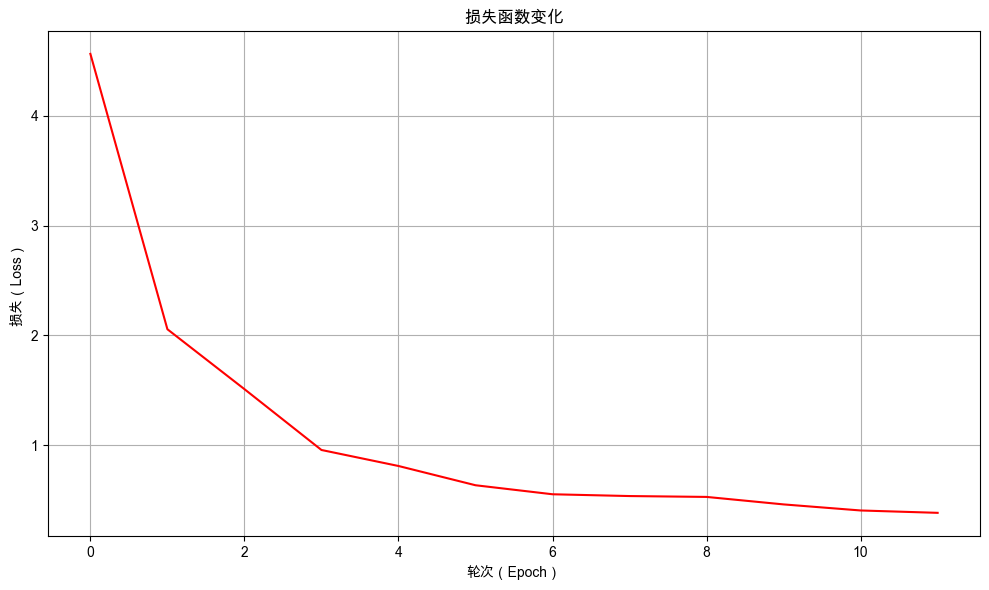

In [17]:
from util import plot_training_loss

plot_training_loss(model.train_epoch_losses)

从图中可以看出随着训练的进行，损失值不断下降，表示模型预测准确性不断提高。

#### 查看模型评估记录

查看训练过程中的评估结果，更直观地观察模型在验证集上的表现。

In [18]:
from util import show_table

show_table(model.eval_accuracies)

,epoch,总样本数,正确样本数,准确率
0,0,2728,1581,0.5795
1,1,2728,1431,0.5246
2,2,2728,1766,0.6474
3,3,2728,1805,0.6617
4,4,2728,1951,0.7152
5,5,2728,2086,0.7647
6,6,2728,2133,0.7819
7,7,2728,1923,0.7049
8,8,2728,2094,0.7676
9,9,2728,2279,0.8354


### 训练后评估

In [19]:
# 直接调用验证函数进行训练评估
trainer.validate(model=model, datamodule=datamodule)

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          2322.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │    0.8511730432510376     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2728.0,
  'total_correct': 2322.0,
  'val_overall_acc': 0.8511730432510376}]

从评估结果中可以看出，训练前的模型的准确率是 `51.17%`，训练后的准确率是 `85.11%`，说明这次模型训练确实有效。

## 使用模型进行预测

在模型训练完成后，需要评估模型的泛化能力。我们准备了一组包含不同长度（短、中、长）且情感倾向明确的评论文本，并调用模型的 `predict` 方法进行推理预测，直观地观察模型在实际应用中的表现。

In [20]:
model.setup_label_map(label_map={0: "负面", 1: "正面"})

from util import print_classification_results

# 1. 准备需要预测的文本（长短不一）与对应的感情标签
new_texts = [
    # 短文本
    "非常好",
    "质量差",
    "推荐购买",
    "不建议买",

    # 中等长度文本
    "这个产品还不错",
    "物流速度太慢了",
    "性价比很高值得推荐",

    # 长文本
    "包装很精美，产品和描述一致，非常满意这次购物体验",
    "卖家服务态度不好，发货速度慢，产品质量也不如预期",
    "虽然价格有点贵，但是品质确实不错，使用效果很满意"
]

true_labels = [1, 0, 1, 0, 1, 0, 1, 1, 0, 1]

# 2. 使用已有的 tokenizer 对文本进行编码
input_ids = []
for text in new_texts:
    encoded = tokenizer(text, max_length=max_length)
    input_ids.append(encoded)

# 3. 使用模型进行预测
predictions, decoded_predictions, probabilities = model.predict(input_ids)

# 4. 输出预测结果
print_classification_results(new_texts, true_labels, predictions, probabilities, model.label_map)

🎯 分类预测结果 (准确率: 5/10 = 50.00%)：
+--------------------------------------------------+----------+----------+----------+------+
|                       输入                       | 真实标签 | 预测标签 | 最高概率 | 标记 |
+--------------------------------------------------+----------+----------+----------+------+
|                      非常好                      |   正面   |   正面   |  0.7041  |  ☑   |
|                      质量差                      |   负面   |   正面   |  0.6130  |  ☒   |
|                     推荐购买                     |   正面   |   正面   |  0.7757  |  ☑   |
|                     不建议买                     |   负面   |   负面   |  0.8575  |  ☑   |
|                  这个产品还不错                  |   正面   |   负面   |  0.6043  |  ☒   |
|                  物流速度太慢了                  |   负面   |   正面   |  0.5382  |  ☒   |
|                性价比很高值得推荐                |   正面   |   负面   |  0.9419  |  ☒   |
| 包装很精美，产品和描述一致，非常满意这次购物体验 |   正面   |   负面   |  0.9761  |  ☒   |
| 卖家服务态度不好，发货速度慢，产品质量也不如预期 |   负面   |   负面   |  0.7494 

从汇总结果中可以清晰地看到，模型在这 10 条新评论上的预测准确率仅为 `50%`。这个极低的准确率表明，尽管模型在训练集和评估集（在本例中初始评估集与训练集相同）上表现良好，但其泛化能力严重不足。当面对全新的、未见过的评论文本时，模型无法做出有效判断。

下面我们使用与训练集不同的评估集重新评估模型的性能。

## 泛化能力评估

使用与训练集不同的评估集重新评估模型的性能，查看模型在新数据上的泛化能力。

In [21]:
from util import print_red

datamodule2 = TextDataModule(batch_size=batch_size, transform=transform,
                             train_data_file="./dataset/comments_train.txt",
                             val_data_file="./dataset/comments_val.txt")

print_red("在训练集上评估：")
trainer.validate(model=model, datamodule=datamodule)

print_red("在评估集上评估：")
trainer.validate(model=model, datamodule=datamodule2)

在训练集上评估：


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          2322.0           │
│       total_samples       │          2728.0           │
│      val_overall_acc      │    0.8511730432510376     │
└───────────────────────────┴───────────────────────────┘

在评估集上评估：


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       total_correct       │          1520.0           │
│       total_samples       │          2789.0           │
│      val_overall_acc      │    0.5449982285499573     │
└───────────────────────────┴───────────────────────────┘

[{'total_samples': 2789.0,
  'total_correct': 1520.0,
  'val_overall_acc': 0.5449982285499573}]

当我们在一个独立的评估集上进行评估时，模型的表现急剧下降，准确率远低于训练集。这是一个典型的过拟合（Overfitting）现象。

为什么会这样呢？

:::{admonition} 思考一下：为何原始序号无法让模型学会“理解”？
:class: note
我们的实验清晰地表明，仅使用分词后的字符ID序号（Token ID）来训练文本分类模型，存在非常严重的过拟合问题。其根源在于我们当前采用的文本表示方法存在根本性缺陷，模型无法从这种表示中学习到有意义的语义规律，只能“死记硬背”训练数据中的表面模式。

直接使用 Token ID 训练模型，本质上是让模型去“背”数字编号，而非“学”语义规律。这就像让一个学生只记忆考卷的题号顺序来答题，而不是理解题目本身，导致模型陷入对数字表面模式的“死记硬背”。

更严重的是，模型难以区分“一个词的含义”和“一个词出现的位置”。当一个 ID 为 999 的字出现在句子的不同位置，对模型来说可能是完全不同的信号，模型存在严重的绝对位置依赖问题。这种**大数对模型来说非常不稳定**，当它位置稍有变化就会引起模型的大幅震荡。

两个情感倾向相同的评论，因为关键 Token 位置差异，最终的输出差异可能很大：

![image.png](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260204182910.png)


两个情感倾向不同的评论，因为关键 Token 位置相同，最终的输出差异却可能很小：

![image.png](https://fasterai-picgo.oss-cn-beijing.aliyuncs.com/20260204182937.png)

所以，我们必须从根本上改进文本的表示方法来改进这一问题。
:::


## 本章小结

本章我们迈出了自然语言处理实践的第一步，成功构建并训练了一个用于情感分析的文本分类模型。不过我们发现，当前模型将文本表示为孤立的字符 ID 序列，尤其词表较大时，模型会过度依赖字符的绝对位置，这容易导致过拟合，从而使泛化能力下降。因此，下一章我们将改进文本表示方法，让模型能更好地理解词语语义。

## 答疑讨论

```{div} alert alert-light simple-tilt custom-card

<a href="https://t.zsxq.com/mAjcy" onclick="LA.track('qa'); return true;">
    <div>
        <div style="display: flex; align-items: center">
            <img src="https://cdn.aibydoing.com/aibydoing/images/aibydoing-pro-icon.svg" style="width: 128px">
            <div style="margin-left: 20px">
                <h4 class="card-title mt-3">答疑讨论</h4>
                <p class="card-text">
                    如果你有任何学习上的疑问，可以评论留言，和我一起讨论。我会抽空回复你的问题，也欢迎你回答其他人的问题。
                </p>
            </div>
        </div>
    </div>
</a>
```